In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
final_analysis_samples = pd.read_csv('../../SV_sample_data/data/final_analysis_samples.csv')
hotspot_event_matrix = pd.read_csv('../../SV_signature_analysis/Clustered_SVs/results/clustered_sv_merged_hotspot_matrix.csv')
hotspot_event_matrix = hotspot_event_matrix[hotspot_event_matrix['sample_id'].isin(final_analysis_samples['tumor_normal_pair'])]
cnv_data = pd.read_hdf('../../SV_sample_data/data/analysis_public_os_data_merged_abs_segfiles_v2.h5')
event_boundaries = pd.read_csv('../../SV_signature_analysis/Clustered_SVs/results/hotspot_event_definitions.csv')

genes = pd.DataFrame([
    {'gene': 'CCND3', 'chrom': '6', 'start': 41934934, 'end': 42050357},
    {'gene': 'MYC', 'chrom': '8', 'start': 127735434, 'end': 127742951},
    {'gene': 'CDK4', 'chrom': '12', 'start': 57747722, 'end': 57756013},
    {'gene': 'CCNE1', 'chrom': '19', 'start': 29811471, 'end': 29824313},
    {'gene': 'MDM2', 'chrom': '12', 'start': 68808172, 'end': 68850686},
    {'gene': 'TP53', 'chrom': '17', 'start': 7668421, 'end': 7687490},

])
event_boundaries

,event,chrom,start,end
0,CCND3,6,39000000,55000000
1,MYC,8,99000000,137000000
2,CDK4-MDM2,12,53000000,75000000
3,CCNE1,19,27000000,34000000
4,TP53,17,7000000,22000000


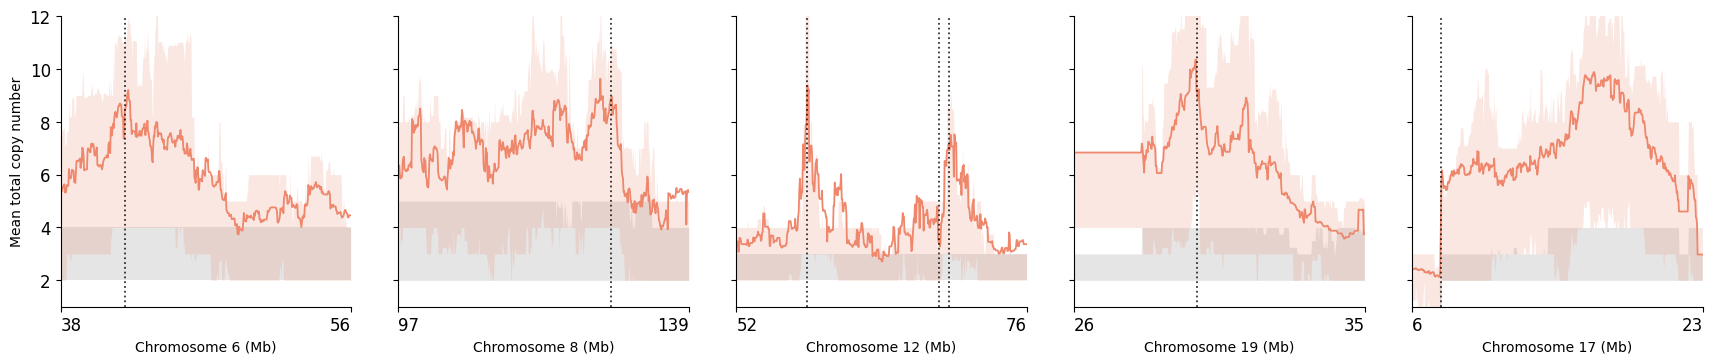

In [5]:
from matplotlib.transforms import blended_transform_factory

BIN_WIDTH = 50_000
N_BINS = 500
BUFFER_FRAC_EACH_END = 0.05
MIN_BUFFER_BP_EACH_END = 1_000_000

event_cols = [c for c in hotspot_event_matrix.columns if c not in ("sample_id", "n_clustered_events")]

def genes_overlapping_region(chrom, e0, e1, genes=genes):
    g = genes[genes["chrom"].astype(int) == int(chrom)].copy()
    ov = (g["end"].astype(int) >= e0) & (g["start"].astype(int) <= e1)
    return g.loc[ov]

def extended_region_and_bin_width(r0, r1):
    L = r1 - r0
    buf = max(MIN_BUFFER_BP_EACH_END, BUFFER_FRAC_EACH_END * L)
    e0, e1 = max(0, r0 - buf), r1 + buf
    bin_w = (e1 - e0) / N_BINS
    return e0, e1, bin_w

def cna_stats_in_bins(chrom, start, end, sample_ids, bin_width=BIN_WIDTH):
    """Returns bin midpoints + mean, Q25, Q75 across samples."""
    edges = np.arange(start, end + bin_width, bin_width)
    b0, b1 = edges[:-1], edges[1:]
    mid = (b0 + b1) / 2

    seg = cnv_data[
        (cnv_data["sample"].isin(sample_ids))
        & (cnv_data["Chromosome"].astype(int) == int(chrom))
    ].copy()
    seg["cn"] = seg["rescaled.cn.a1"].astype(float) + seg["rescaled.cn.a2"].astype(float)

    means, q25s, q75s = [], [], []
    for lo, hi in zip(b0, b1):
        vals = []
        for sid, g in seg.groupby("sample"):
            num, den = 0.0, 0.0
            for _, r in g.iterrows():
                o0 = max(float(r["Start.bp"]), lo)
                o1 = min(float(r["End.bp"]), hi)
                w = o1 - o0
                if w > 0:
                    num += r["cn"] * w
                    den += w
            if den > 0:
                vals.append(num / den)
        if vals:
            means.append(np.mean(vals))
            q25s.append(np.percentile(vals, 25))
            q75s.append(np.percentile(vals, 75))
        else:
            means.append(np.nan); q25s.append(np.nan); q75s.append(np.nan)

    return mid, np.array(means), np.array(q25s), np.array(q75s)


n_events = len(event_cols)
fig, axes = plt.subplots(1, n_events, figsize=(3.5 * n_events, 3.5))
if n_events == 1:
    axes = [axes]

for ax, ev in zip(axes, event_cols):
    row = event_boundaries[event_boundaries["event"] == ev].iloc[0]
    chrom = int(row["chrom"])
    r0, r1 = int(row["start"]), int(row["end"])
    e0, e1, bin_w = extended_region_and_bin_width(r0, r1)

    pos = hotspot_event_matrix.loc[hotspot_event_matrix[ev] == 1, "sample_id"]
    pos = pos[pos.isin(cnv_data["sample"].unique())]

    neg = hotspot_event_matrix.loc[hotspot_event_matrix[ev] == 0, "sample_id"]
    neg = neg[neg.isin(cnv_data["sample"].unique())]

    x, ymean, yq25, yq75 = cna_stats_in_bins(chrom, e0, e1, pos.tolist(), bin_width=bin_w)
    _, _, yq25_neg, yq75_neg = cna_stats_in_bins(chrom, e0, e1, neg.tolist(), bin_width=bin_w)
    xmb = x / 1e6

    # gray ribbon for non-event background
    ax.fill_between(xmb, yq25_neg, yq75_neg, color="#ccccccff", alpha=0.5, linewidth=0)
    # crimson ribbon + mean line for event samples
    ax.fill_between(xmb, yq25, yq75, color="#ee876cda", alpha=0.20, linewidth=0)
    ax.plot(xmb, ymean, color="#ee876cff", lw=1.3)

    # gene annotations
    hits = genes_overlapping_region(chrom, e0, e1)
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    for _, gg in hits.iterrows():
        mid_mb = (int(gg["start"]) + int(gg["end"])) / 2e6
        ax.axvline(mid_mb, color="black", ls=':', lw=1.3, alpha=0.8)

    ax.set_xlim(e0 / 1e6, e1 / 1e6)
    ax.set_ylim(1, 12)
    ax.set_xlabel(f"Chromosome {chrom} (Mb)", fontsize=10)
    ax.set_box_aspect(1)
    ax.tick_params(labelsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if ax == axes[0]:
        ax.set_ylabel("Mean total copy number", fontsize=10)
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    # c) every other x-tick label
    # label only start/end of the x-axis window
    x0 = e0 / 1e6
    x1 = e1 / 1e6
    ax.set_xticks([x0, x1])
    ax.set_xticklabels([f"{x0:.0f}", f"{x1:.0f}"], fontsize=12)
    labels = ax.get_xticklabels()
    labels[0].set_ha('left')
    labels[1].set_ha('right')

plt.tight_layout()
plt.savefig("../results/aggregate_cn_profiles.pdf", bbox_inches="tight")
plt.show()